In [26]:
from dotenv import load_dotenv
import os
import numpy as np
import matplotlib.pyplot as plt
import utils
import importlib 
importlib.reload(utils)
from utils import load_images

In [27]:
load_dotenv()
WIDTH, HEIGHT, CHANNELS = int(os.getenv('WIDTH')), int(os.getenv('HEIGHT')), int(os.getenv('CHANNELS'))
MAIN_DIR = os.getenv('MAIN_DIR')


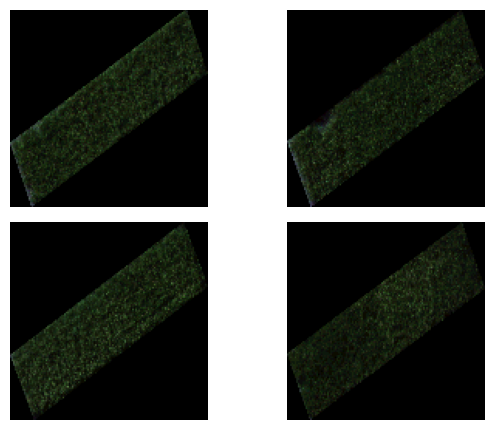

In [28]:
real_images_15, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30', "_HEALTHY.tif")
real_images_30, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24', "_HEALTHY.tif")
real_images_40, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-05', "_HEALTHY.tif")
real_images_42, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07', "_HEALTHY.tif")
subplots = (2, 2)  # Define the subplot arrangement (2x2 grid)

# Define a function to create a mask for non-black pixels
def create_non_black_mask(image):
    # Convert the image to numpy array
    img_array = np.array(image)
    
    # Create a mask selecting non-black pixels (where sum across channels is not zero)
    non_black_mask = np.sum(img_array, axis=-1) != 0
    
    return non_black_mask

# Create masks for all images
non_black_mask = create_non_black_mask(real_images_42[0])

for i, image in enumerate(real_images_42[:4]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        image = (image - image.min()) / (image.max() - image.min())
        plt.imshow(image[:, :, :3])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
def compute_groupwise_spectral_profiles(images_groups):
    groupwise_spectral_profiles = []
    
    for images_group in images_groups:
        spectral_profiles = []
        
        for image in images_group:
            spectral_profile = np.mean(image, axis=(0, 1))
            spectral_profiles.append(spectral_profile)
        
        mean_spectral_profile = np.mean(spectral_profiles, axis=0)
        groupwise_spectral_profiles.append(mean_spectral_profile)
    
    return groupwise_spectral_profiles


def compute_spectral_profile(image):
    # Assuming image is of shape (128, 128, 5)
    spectral_profile = np.mean(image, axis=(0, 1))
    return spectral_profile


(128, 128, 5)


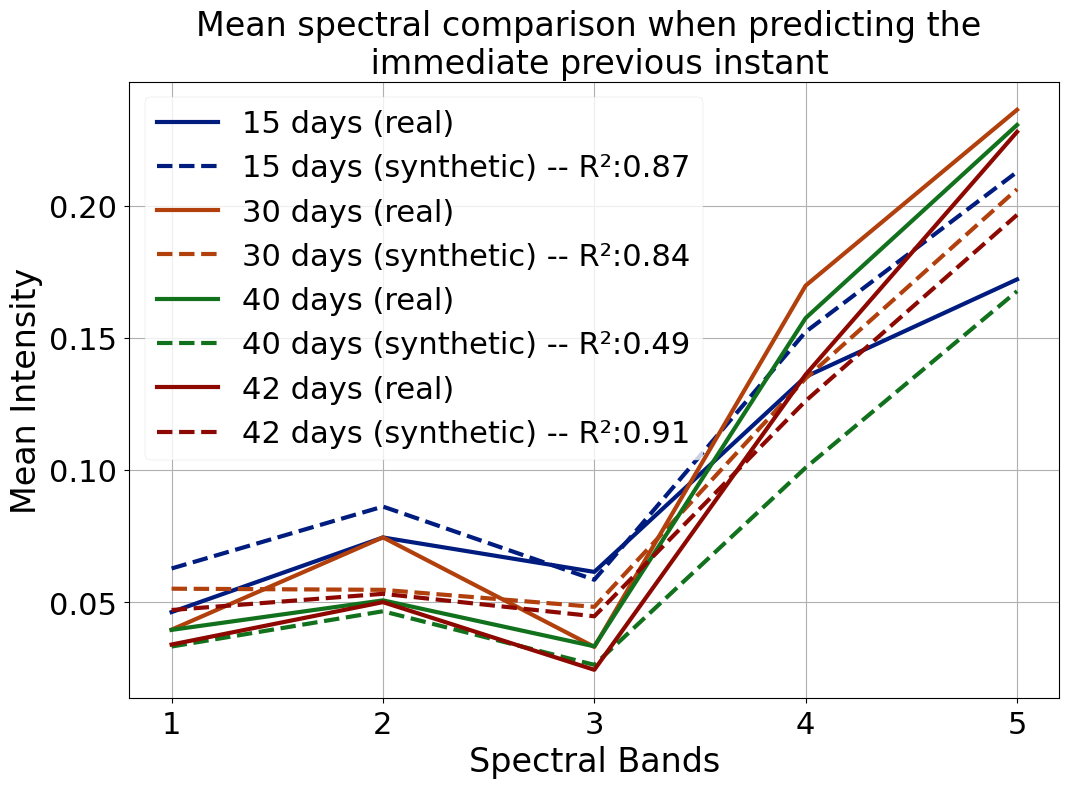

In [58]:
from sklearn.metrics import r2_score
import seaborn as sns


real_images_15, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30', "_HEALTHY.tif")
real_images_30, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24', "_HEALTHY.tif")
real_images_40, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-05', "_HEALTHY.tif")
real_images_42, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07', "_HEALTHY.tif")
real_images_59, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-26', "_HEALTHY.tif")

real_images_list = [
    real_images_15, 
    real_images_30,
    real_images_40,
    real_images_42,
    real_images_59
]

synthetic_images_15, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30-temporal-synthetic', "0924-15-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_15_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30-temporal-synthetic', "0924-15-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_20, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-05-temporal-synthetic', "0924-20-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_20_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-05-temporal-synthetic', "0924-20-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_30, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24-temporal-synthetic', "1005-30-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_30_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24-temporal-synthetic', "1005-30-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_35, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-29-temporal-synthetic', "1005-35-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_35_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-29-temporal-synthetic', "1005-35-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_40, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-05-temporal-synthetic', "1007-40-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_40_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-05-temporal-synthetic', "1007-40-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_42, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07-temporal-synthetic', "1026-42-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_42_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07-temporal-synthetic', "1026-42-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_45, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07-temporal-synthetic', "1026-45-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_45_2, _ = load_images(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-07-temporal-synthetic', "1026-45-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")

print(synthetic_images_30[0].shape)

synthetic_image_variables = [
    synthetic_images_15, synthetic_images_15_2,
    #synthetic_images_20, synthetic_images_20_2,
    synthetic_images_30, synthetic_images_30_2,
    #synthetic_images_35, synthetic_images_35_2,
    synthetic_images_40, synthetic_images_40_2,
    synthetic_images_42, synthetic_images_42_2
]

synthetic_images_list = []

for synthetic_images, synthetic_images_2 in zip(synthetic_image_variables[::2], synthetic_image_variables[1::2]):
    # Define an empty list to store the processed results
    result_with_mask = []
    # Calculate mask for black pixels in images (assuming create_non_black_mask is a function that generates the mask)
    black_pixels_mask = create_non_black_mask(real_images_15[0]) == 0  # Assuming the first image is representative

    # Process images using masks
    result = [
        (((x - (y/10)) / 2) * 2) if x.all != 0 else x
        for x, y in zip(synthetic_images, synthetic_images_2)
    ]

    # Apply the mask to processed images
    for i, img in enumerate(result):
        img[:, :, 0][black_pixels_mask] = 0
        img[:, :, 1][black_pixels_mask] = 0
        img[:, :, 2][black_pixels_mask] = 0
        img[:, :, 3][black_pixels_mask] = 0
        img[:, :, 4][black_pixels_mask] = 0

    # Reshape the processed images
    synthetic_images_list.append(result)

# Calculate mean spectral profiles for synthetic_images_list and real_images_list
synthetic_mean_profiles = compute_groupwise_spectral_profiles(synthetic_images_list)
real_mean_profiles = compute_groupwise_spectral_profiles(real_images_list)

# Create a figure
plt.figure(figsize=(12, 8))

labels_synthetic_profiles = ['15 days (synthetic)', '30 days (synthetic)', '40 days (synthetic)', '42 days (synthetic)']
labels_real_profiles = ['15 days (real)', '30 days (real)', '40 days (real)', '42 days (real)', '59 days (real)']
labels = ['Band 1', 'Band 2', 'Band 3', 'Band 4', 'Band 5 (RE)']  # Assuming Band 5 is RE band
# Define a green color palette with as many shades as the number of days
palette = sns.color_palette("dark")

# Plotting synthetic and real spectral profiles with custom x-axis ticks
for idx, (synthetic_profile, real_profile) in enumerate(zip(synthetic_mean_profiles, real_mean_profiles)):
    r_squared = r2_score(synthetic_profile, real_profile)
    x_values = np.linspace(1, 5, len(synthetic_profile))  # Bands 1 to 5 for each set of profiles
    color = palette[idx % len(palette)]  # Cyclically select colors from the palette

    plt.plot(x_values, real_profile, label=labels_real_profiles[idx], color=color, linewidth=3)
    plt.plot(x_values, synthetic_profile, linestyle='--', label=f'{labels_synthetic_profiles[idx]} -- R²:{r_squared:.2f}', color=color, linewidth=3)

plt.xlabel('Spectral Bands', fontsize=24)
plt.ylabel('Mean Intensity', fontsize=24)
plt.title('Mean spectral comparison when predicting the \n immediate previous instant', fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=22) # Adjust the font size for tick labels

plt.legend(fontsize=22)  # Adjust the font size for the legend
plt.grid(True)

# Set custom ticks for the x-axis (show only integer values)
plt.xticks(np.arange(1, 6, 1))
plt.savefig('output-spectral-mean.pdf')
plt.show()

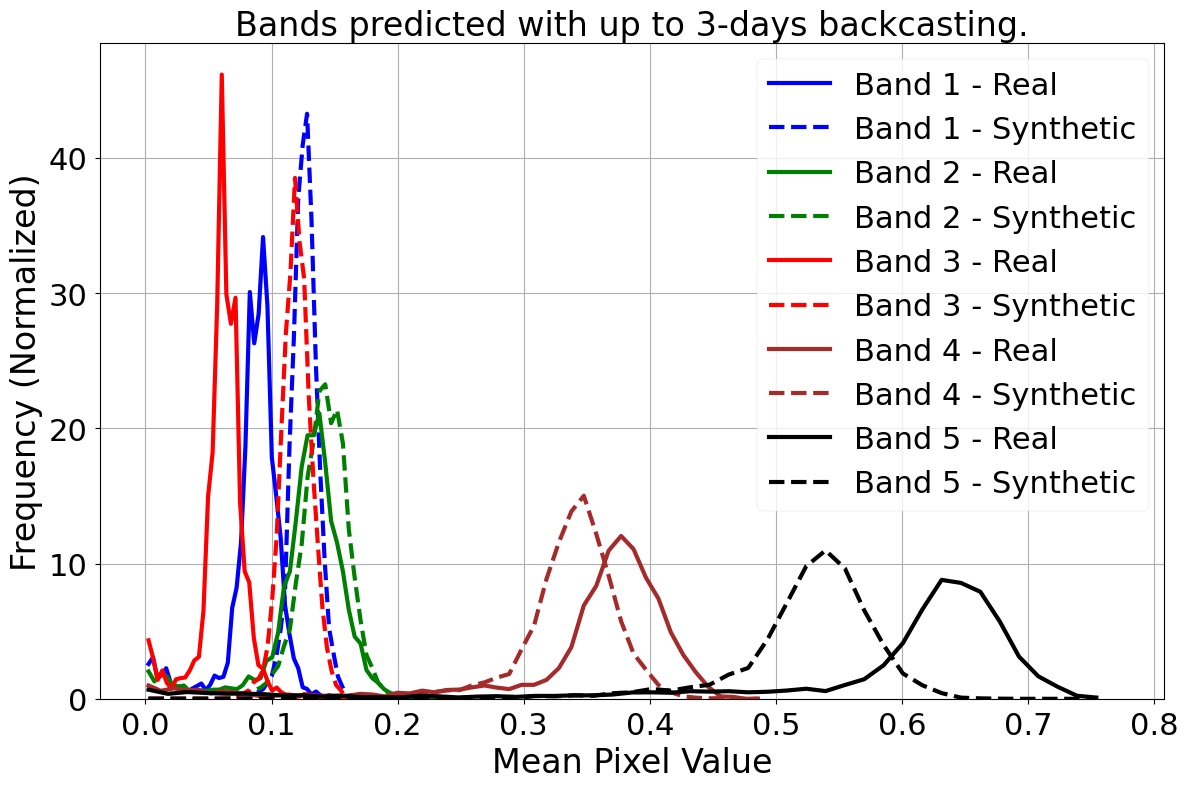

In [50]:

# Selecting the specific images from the lists
real_images = real_images_list[3]  # Selecting the position 1 from real_images_list
synthetic_images = synthetic_images_list[3]  # Selecting the position 1 from synthetic_image_variables
synthetic_images = np.stack(synthetic_images, axis=0)

# Calculate mean pixel values for each band across all samples
mean_real = np.mean(real_images, axis=0)  # Shape will be (128, 128, 5) representing mean of each band
mean_synthetic = np.mean(synthetic_images, axis=0)  # Shape will be (128, 128, 5) representing mean of each band

# Filter out values equal to 0.0 for each band across all samples
for i in range(mean_real.shape[-1]):
    mean_real[mean_real[..., i] == 0.0, i] = np.nan
    mean_synthetic[mean_synthetic[..., i] == 0.0, i] = np.nan

num_bins = 50  # Number of bins for histogram-like plot
labels = ['Band 1', 'Band 2', 'Band 3', 'Band 4', 'Band 5']  # Assuming Band 5 is RE band
colors = ['blue', 'green', 'red', 'brown', 'black']  # Assigning colors to bands

# Setting seaborn-paper style
plt.style.use('seaborn-paper')

plt.figure(figsize=(12, 8))

for band_idx in range(mean_real.shape[-1]):
    real_values = np.sort(mean_real[..., band_idx].flatten())
    synthetic_values = np.sort(mean_synthetic[..., band_idx].flatten())
    real_freq, bins, _ = plt.hist(real_values, bins=num_bins, alpha=0, density=True, color=colors[band_idx])
    synthetic_freq, _, _ = plt.hist(synthetic_values, bins=bins, alpha=0, density=True, color=colors[band_idx])
    plt.plot(bins[:-1], real_freq, label=f'{labels[band_idx]} - Real', linestyle='solid', color=colors[band_idx], linewidth=3)
    plt.plot(bins[:-1], synthetic_freq, label=f'{labels[band_idx]} - Synthetic', linestyle='dashed', color=colors[band_idx], linewidth=3)

plt.xlabel('Mean Pixel Value', fontsize=24)  # Adjust the font size for the x-axis label
plt.ylabel('Frequency (Normalized)', fontsize=24)  # Adjust the font size for the y-axis label
plt.title('Bands predicted with up to 3-days backcasting.', fontsize=24)  # Adjust the font size for the title
plt.legend(fontsize=22)  # Adjust the font size for the legend
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=22)  # Adjust the font size for tick labels
plt.tight_layout()
plt.savefig('output-frequency.pdf')
plt.show()

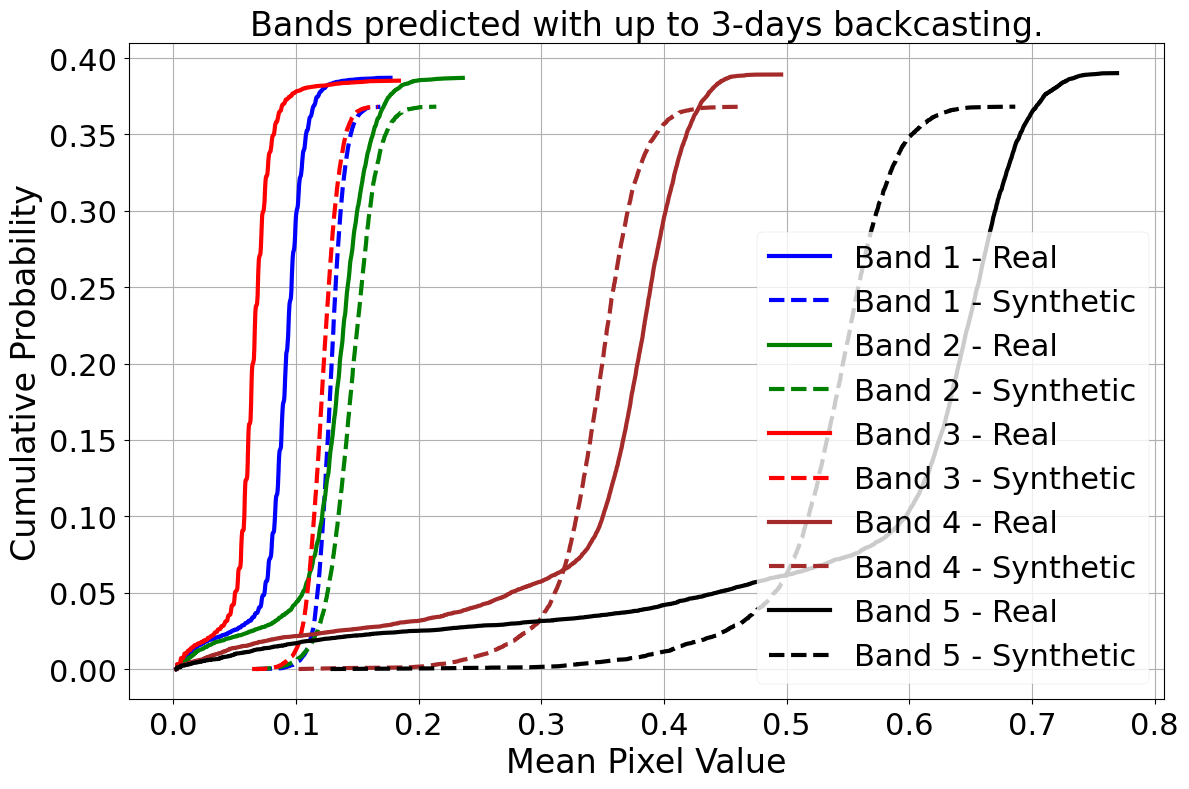

In [51]:
plt.figure(figsize=(12, 8))

for band_idx in range(mean_real.shape[-1]):
    real_values = np.sort(mean_real[..., band_idx].flatten())
    synthetic_values = np.sort(mean_synthetic[..., band_idx].flatten())
    plt.plot(real_values, np.linspace(0, 1, len(real_values)), label=f'{labels[band_idx]} - Real', linestyle='solid', color=colors[band_idx], linewidth=3)
    plt.plot(synthetic_values, np.linspace(0, 1, len(synthetic_values)), label=f'{labels[band_idx]} - Synthetic', linestyle='dashed', color=colors[band_idx], linewidth=3)

plt.xlabel('Mean Pixel Value', fontsize=24)
plt.ylabel('Cumulative Probability', fontsize=24)
plt.title('Bands predicted with up to 3-days backcasting.', fontsize=24)
plt.legend(fontsize=22)  # Adjust the font size for the legend
plt.tick_params(axis='both', which='major', labelsize=22) # Adjust the font size for tick labels

plt.grid(True)
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('output-probability-density.pdf')

plt.show()

4
[0.06281571, 0.055176467, 0.047110565]
[0.086241305, 0.054747004, 0.053241067]
[0.05854992, 0.048299957, 0.044740126]
[0.1523378, 0.13472176, 0.12622425]
[0.21282518, 0.20626922, 0.19657469]


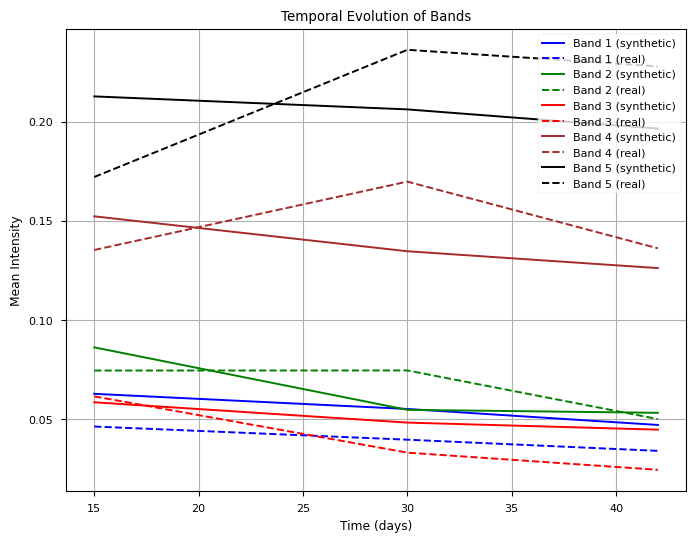

In [55]:
import matplotlib.pyplot as plt

# Assuming you have synthetic_mean_profiles and real_mean_profiles defined as lists of lists with band values for different time points

# Plotting the temporal evolution of each band in a single chart
time_points = [15, 30, 42]  # Time points for the profiles

band_1_values = []
band_2_values = []
band_3_values = []
band_4_values = []
band_5_values = []

band_1_synthetic_values = []
band_2_synthetic_values = []
band_3_synthetic_values = []
band_4_synthetic_values = []
band_5_synthetic_values = []

print(len(synthetic_mean_profiles))

for instant in range(len(synthetic_mean_profiles)):
    if instant != 2:
        band_1_values.append(real_mean_profiles[instant][0])
        band_2_values.append(real_mean_profiles[instant][1])
        band_3_values.append(real_mean_profiles[instant][2])
        band_4_values.append(real_mean_profiles[instant][3])
        band_5_values.append(real_mean_profiles[instant][4])
        band_1_synthetic_values.append(synthetic_mean_profiles[instant][0])
        band_2_synthetic_values.append(synthetic_mean_profiles[instant][1])
        band_3_synthetic_values.append(synthetic_mean_profiles[instant][2])
        band_4_synthetic_values.append(synthetic_mean_profiles[instant][3])
        band_5_synthetic_values.append(synthetic_mean_profiles[instant][4])

synthetic_bands = [band_1_synthetic_values, band_2_synthetic_values, band_3_synthetic_values, band_4_synthetic_values, band_5_synthetic_values]
real_bands = [band_1_values, band_2_values, band_3_values, band_4_values, band_5_values]
band_labels = ['Band 1', 'Band 2', 'Band 3', 'Band 4', 'Band 5']

plt.figure(figsize=(8, 6))

for i in range(len(synthetic_bands)):
    print(synthetic_bands[i])
    plt.plot(time_points, synthetic_bands[i], label=f"{band_labels[i]} (synthetic)", color=colors[i])
    plt.plot(time_points, real_bands[i], linestyle='--', label=f"{band_labels[i]} (real)", color=colors[i])

plt.xlabel('Time (days)')
plt.ylabel('Mean Intensity')
plt.title('Temporal Evolution of Bands')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
import pandas as pd
df = []
df_target = []

def dataset_load():
    df = []
    df1 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24-temporal-synthetic\VALUES\values.csv')
    #df2 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    #df3 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\VALUES\values.csv')
    #df4 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\VALUES\values.csv')
    #df5 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\VALUES\values.csv')
    #df6 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\08-30-2021\VALUES\values.csv')
    #df7 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\09-24-2021\VALUES\values.csv')
    #df8 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-05-2021\VALUES\values.csv')
    #df9 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-07-2021\VALUES\values.csv')
    #df10 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-26-2021\VALUES\values.csv')
    df.append(df1)
    #df.append(df2)
    #df.append(df3)
    #df.append(df4)
    #df.append(df5)
    #df.append(df6)
    #df.append(df7)
    #df.append(df8)
    #df.append(df9)
    #df.append(df10)
    df = pd.concat(df, ignore_index=True)
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\09-24\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    return df, df_target


def clean_dataframe(df, ignore_label):
    # Select all columns except the label column
    columns_to_clean = df.columns.drop(ignore_label)

    # Compute the mean of selected columns
    mean_values = df[columns_to_clean].mean()

    # Replace NaN values with the mean inplace for selected columns
    df[columns_to_clean] = df[columns_to_clean].fillna(mean_values)
    return df


def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers


df, df_target = dataset_load()
# Remove unnamed columns:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = clean_dataframe(df, 'HEALTH_STA')
#df = remove_outliers_iqr(df, 'HEALTH_STA')
df = df[df['HEALTH_STA'].notna()]
# DROP COLUMNS WITH ALL ROWS AS NAN OR EMPTY:
df = df.dropna(axis=1, how='all')
# Select only HEALTH_STA == 'HEALTHY' or HEALTH_STA == 'UNHEALTHY':
df = df[df['HEALTH_STA'] != 'AVARAGE']
df_target = clean_dataframe(df_target, 'HEALTH_STA')
df_target = df_target[df_target['HEALTH_STA'].notna()]



In [ ]:
import os
import shutil

source_folder = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\synthetic-temporal'  # Replace with the path to your source folder
destination_folder = r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\10-15-temporal-synthetic'  # Replace with the path to your destination folder

for i in range(20):  # Iterate through numbers from 0 to 19
    prefix = f'synthetic_image_{i}_1026-50'  # Formats the number with leading zeros (e.g., 00, 01, ..., 19)
    for filename in os.listdir(source_folder):
        if filename.startswith(prefix) and filename.endswith('.tiff'):
            source_file_path = os.path.join(source_folder, filename)
            destination_file_path = os.path.join(destination_folder, filename)
            shutil.move(source_file_path, destination_file_path)

In [ ]:
    # Visualize the first four reshaped images for this set
    # for i, image in enumerate(reshaped_images[:4]):
    #     if CHANNELS == 1:
    #         plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    #     else:        
    #         print(image.shape)
    #         plt.imshow(image[:, :, :3])
    #     plt.axis("off")
    #     plt.show()  # Show each image individually

    # If you prefer to show all four images in one figure:
    # fig, axes = plt.subplots(1, 4, figsize=(12, 3))  # Adjust figsize as needed

    # for i, image in enumerate(reshaped_images[:4]):
    #     if CHANNELS == 1:
    #         axes[i].imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    #     else:        
    #         print(image.shape)
    #         axes[i].imshow(image[:, :, :3])
    #     axes[i].axis("off")

    # plt.tight_layout()
    # plt.show()  # Show all four images together

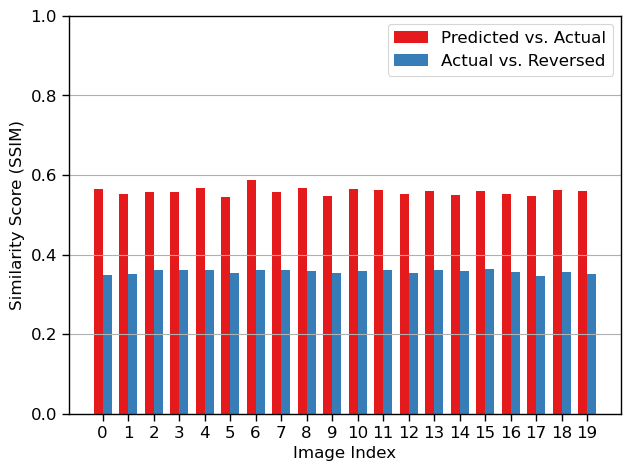

In [5]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import seaborn as sns
sns.set_context('paper')
palette = sns.color_palette('Set1') # Default color palette


def calculate_similarity(image1, image2):
    # Calculate SSIM between two images with a smaller window size and data_range
    return ssim(image1, image2, multichannel=True, win_size=5, data_range=image1.max() - image1.min())

# Calculate similarity between corresponding images in the dataset and their reversed counterparts
similarity_scores = [calculate_similarity(real_images[i], result[i]) for i in range(len(result))]
baseline_scores = [calculate_similarity(real_images[i], real_images[i][::-1]) for i in range(len(result))]

# Set the custom color palette
sns.set_palette(palette)

# Plotting the similarity scores using bar plots

bar_width = 0.35  # Width of the bars

# Calculate positions for bars
index = range(len(result))
bar1 = [i - bar_width/2 for i in index]
bar2 = [i + bar_width/2 for i in index]

# Plotting bars for predicted vs. actual and actual vs. reversed
plt.bar(bar1, similarity_scores, bar_width, label='Predicted vs. Actual')
plt.bar(bar2, baseline_scores, bar_width, label='Actual vs. Reversed')

plt.xlabel('Image Index', fontsize=12)  # Increase font size for x-label
plt.ylabel('Similarity Score (SSIM)', fontsize=12)  # Increase font size for y-label
plt.legend(fontsize=12)  # Increase font size for legend
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.xticks(index, fontsize=12)  # Increase font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase font size for y-axis ticks
plt.grid(axis='y')  # Show grid for y-axis only
plt.tight_layout()  # Adjust layout for better display of labels
plt.savefig('paper-gnn-gan/similarity_comparison.pdf', format='pdf')

plt.show()

In [35]:
import os
import importlib 
import sys
sys.path.append('../multispectral_generative_models')

import dgl
import gnn.utils
import importlib 
importlib.reload(gnn.utils)
from gnn.utils import load_images_and_create_gnn_dataset, load_synthetic_images_and_create_gnn_dataset

def load_data(type='synthetic', dir=MAIN_DIR, days=30, m=9, d=24):
    dataset = []
    if type == 'synthetic':
        dataset.append(load_synthetic_images_and_create_gnn_dataset(dir, days))

    else:
        # Iterate over subdirectories (folders with dates) in MAIN_DIR
        for date_folder in os.listdir(dir):
            # Create the full path to the date folder
            date_folder_path = os.path.join(dir, date_folder)

            # Check if it's a directory (to exclude files)
            if os.path.isdir(date_folder_path):
                folder_name = os.path.basename(date_folder_path)

                if folder_name[-2:].isdigit():
                    # Extract the MM and DD values from the folder name
                    mm, dd = date_folder.split('-')
                    mm = int(mm)
                    dd = int(dd)
                    if type == 'real' and mm == m and dd == d:
                        dataset.append(load_images_and_create_gnn_dataset(date_folder_path, mm, dd))

    return dataset

real_dataset = load_data(type='real', dir=MAIN_DIR, days=30, m=9, d=24)
real_dataset_2 = load_data(type='real', dir=MAIN_DIR, days=40, m=10, d=5)
synthetic_dataset = load_data(type='synthetic', 
                                dir=r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal',
                                days=35)
synthetic_dataset_2 = load_data(type='synthetic', 
                                dir=r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal',
                                days=40)


/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [36]:
# Combine the datasets
data = []
data.append(real_dataset)
data.append(synthetic_dataset)
data.append(synthetic_dataset_2)
data.append(real_dataset_2)
print(data[1])

[Dataset("custom_gnn_dataset", num_graphs=40, save_path=/Users/felipealencar/.dgl/custom_gnn_dataset)]


1


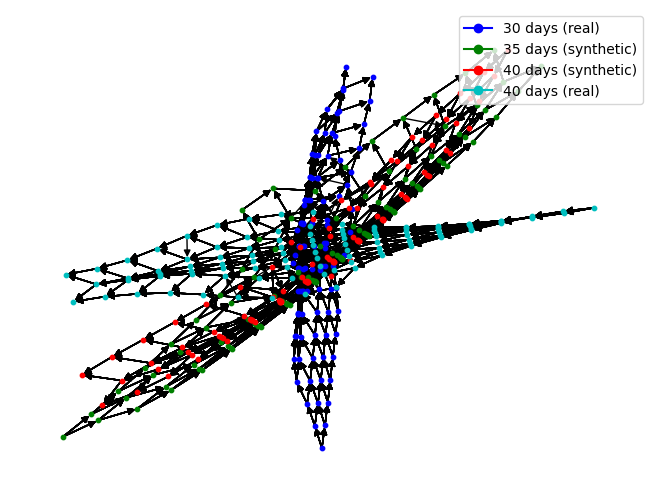

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Create a single plot to display all datasets
plt.figure()

# Define a list of colors for different datasets
colors = ['b', 'g', 'r', 'c']

# Define captions and colors for each dataset
dataset_info = [
    {"caption": "30 days (real)", "color": "b"},
    {"caption": "35 days (synthetic)", "color": "g"},
    {"caption": "40 days (synthetic)", "color": "r"},
    {"caption": "40 days (real)", "color": "c"},
]

# Create handles and labels for the legend
legend_handles = []
legend_labels = []

print(len(data[0]))

# Iterate through each dataset with a unique color and caption
for i, d in enumerate(data):
    if not d:  # Check if the dataset is empty
        continue

    # Get the first graph in the current dataset
    graph, _ = d[0][0]

    # Sample a subset of nodes (e.g., 100 nodes) for visualization
    shape_first_graph = graph.number_of_nodes()
    sampled_nodes = random.sample(range(shape_first_graph), 0)

    # Create a subgraph with the sampled nodes
    subgraph = graph.subgraph(sampled_nodes)

    # Convert the subgraph to NetworkX graph and plot it with a unique color
    G = subgraph.to_networkx()
    pos = nx.kamada_kawai_layout(G)  # Layout algorithm (you can choose a different one)
    nx.draw(G, pos, with_labels=False, node_color=colors[i], node_size=10)



    # Add a caption for the current dataset with its associated color
    dataset = dataset_info[i]

    legend_handles.append(plt.Line2D([0], [0], marker='o', color=dataset["color"], label=dataset["caption"]))

# Show the legend
plt.legend(handles=legend_handles, loc='upper right')

# Show the combined plot
plt.show()

imagem_segmentada_118_0924_UNHEALTHY.tif
imagem_segmentada_135_0924_UNHEALTHY.tif
imagem_segmentada_156_0924_UNHEALTHY.tif
imagem_segmentada_138_0924_UNHEALTHY.tif
imagem_segmentada_18_0924_UNHEALTHY.tif
imagem_segmentada_193_0924_UNHEALTHY.tif
imagem_segmentada_158_0924_UNHEALTHY.tif
imagem_segmentada_155_0924_UNHEALTHY.tif
imagem_segmentada_55_0924_UNHEALTHY.tif
imagem_segmentada_95_0924_UNHEALTHY.tif
imagem_segmentada_173_0924_UNHEALTHY.tif
imagem_segmentada_88_0924_UNHEALTHY.tif
imagem_segmentada_6_0924_UNHEALTHY.tif
imagem_segmentada_50_0924_UNHEALTHY.tif
imagem_segmentada_12_0924_UNHEALTHY.tif
imagem_segmentada_161_0924_UNHEALTHY.tif
imagem_segmentada_22_0924_UNHEALTHY.tif
imagem_segmentada_99_0924_UNHEALTHY.tif
imagem_segmentada_152_0924_UNHEALTHY.tif
imagem_segmentada_72_0924_UNHEALTHY.tif
imagem_segmentada_189_0924_UNHEALTHY.tif
imagem_segmentada_159_0924_UNHEALTHY.tif
imagem_segmentada_154_0924_UNHEALTHY.tif
imagem_segmentada_34_0924_UNHEALTHY.tif
imagem_segmentada_91_0924_UN

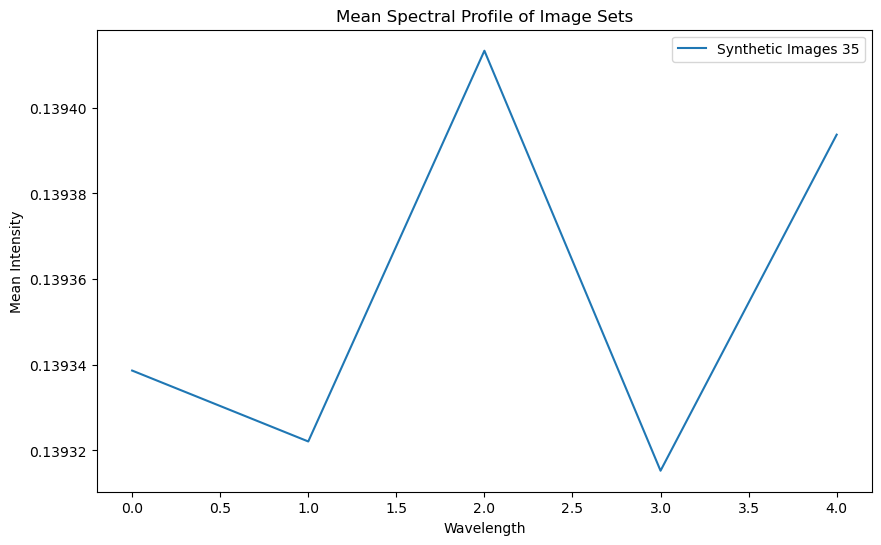

In [136]:
# Define a function to create a mask for non-black pixels
def create_non_black_mask(image):
    # Convert the image to numpy array
    img_array = np.array(image)
    
    # Create a mask selecting non-black pixels (where sum across channels is not zero)
    non_black_mask = np.sum(img_array, axis=-1) != 0
    
    return non_black_mask

real_images_42, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/09-24/', "_UNHEALTHY.tif")
real_images_40, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/10-05/', "_UNHEALTHY.tif")
synthetic_images_42, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "synthetic_image_19_1007-35-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_42_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1007-35-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_40, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-40-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_40_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-40-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")

# Define an empty list to store the processed results
result_with_mask = []

# # Calculate mask for black pixels in images

# black_pixels_mask = create_non_black_mask(real_images_30.reshape(-1, 5, 128, 128)[0]) == 0  # Assuming the first image is representative
# subplots = (2, 2)  # Define the subplot arrangement (2x2 grid)

# # Modify images2 in the region where images has black pixels
# for i, img in enumerate(synthetic_images_35_2):
#     print(img.shape)
#     img[black_pixels_mask] = 0

# # Process images using masks
# result = [
#     (((x - (y/10)) / 2) * 3) if x.all != 0 else x
#     for x, y in zip(synthetic_images_35, synthetic_images_35_2)
# ]

# # Modify images2 in the region where images has black pixels
# for i, img in enumerate(result):
#     img[black_pixels_mask] = 0
#     img[:, :, 2] = img[:, :, 2]
#     img[:, :, 1] = img[:, :, 1]
#     img[:, :, 0] = img[:, :, 0]

import numpy as np
import matplotlib.pyplot as plt

# Load your images here (assuming they're loaded into the variables mentioned)
print(real_images_42.shape)
print(synthetic_images_42.reshape(-1, 128, 128, 5).shape)
# Calculate the mean spectrum for each set of images
real_images_30_mean_spectrum = np.mean(np.ma.masked_equal(real_images_42, 0), axis=(0, 1, 2))
real_images_40_mean_spectrum = np.mean(np.ma.masked_equal(real_images_40, 0), axis=(0, 1, 2))
synthetic_images_35_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_42.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_35_2_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_42_2.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_40_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_40.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_40_2_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_40_2.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))

print(synthetic_images_35_2_mean_spectrum)

# Plotting the mean spectra
wavelengths = range(len(synthetic_images_35_mean_spectrum))  # Assuming your images are grayscale and have same dimensions

plt.figure(figsize=(10, 6))

#plt.plot(wavelengths, real_images_30_mean_spectrum, label='Real Images 30')
#plt.plot(wavelengths, real_images_40_mean_spectrum, label='Real Images 40')
plt.plot(wavelengths, synthetic_images_35_mean_spectrum, label='Synthetic Images 35')
#plt.plot(wavelengths, synthetic_images_35_2_mean_spectrum, label='Synthetic Images 35_2')
#plt.plot(wavelengths, synthetic_images_40_mean_spectrum, label='Synthetic Images 40')
#plt.plot(wavelengths, synthetic_images_40_2_mean_spectrum, label='Synthetic Images 40_2')

plt.xlabel('Wavelength')
plt.ylabel('Mean Intensity')
plt.title('Mean Spectral Profile of Image Sets')
plt.legend()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


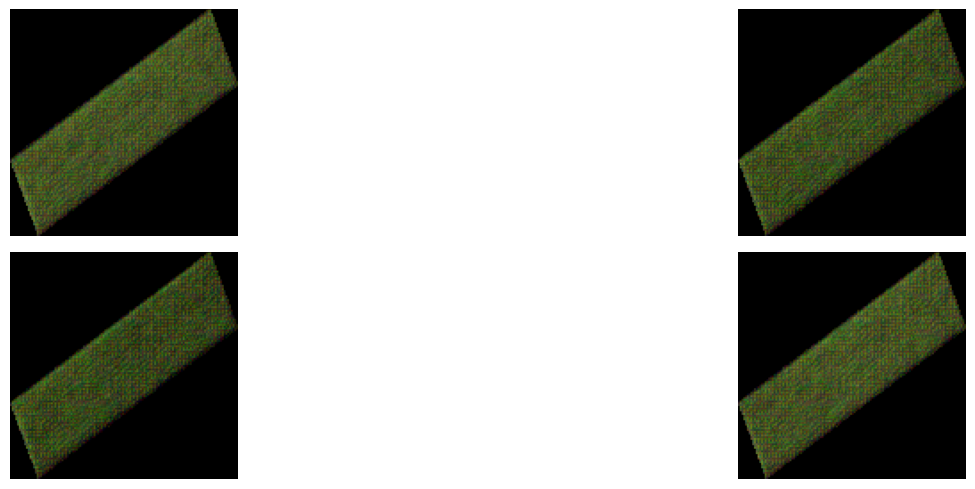

In [148]:
subplots = (2, 2)
plt.figure(figsize=(20,5))
synthetic_images_42, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_42_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
# Define an empty list to store the processed results
# Define an empty list to store the processed results
result_with_mask = []

# Calculate mask for black pixels in images

black_pixels_mask = create_non_black_mask(real_images_42[0]) == 0  # Assuming the first image is representative

# Modify images2 in the region where images has black pixels
for i, img in enumerate(synthetic_images_42_2):
    img[black_pixels_mask] = 0

# Process images using masks
result = [
    (((x - (y / 10)) / 2) * 5) if x.all != 0 else x
    for x, y in zip(synthetic_images_42, synthetic_images_42_2)
]

samples_ppgan3_array_0924 = result
# Modify images2 in the region where images has black pixels
for i, img in enumerate(result):
    img[black_pixels_mask] = 0
    img[:, :, 2] = img[:, :, 2]/2.5
    img[:, :, 1] = img[:, :, 1]/1.5
    img[:, :, 0] = img[:, :, 0]/1.5

for i, image in enumerate(result[16:20]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        print(image.shape)
        plt.imshow(image[:, :, :])
    plt.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


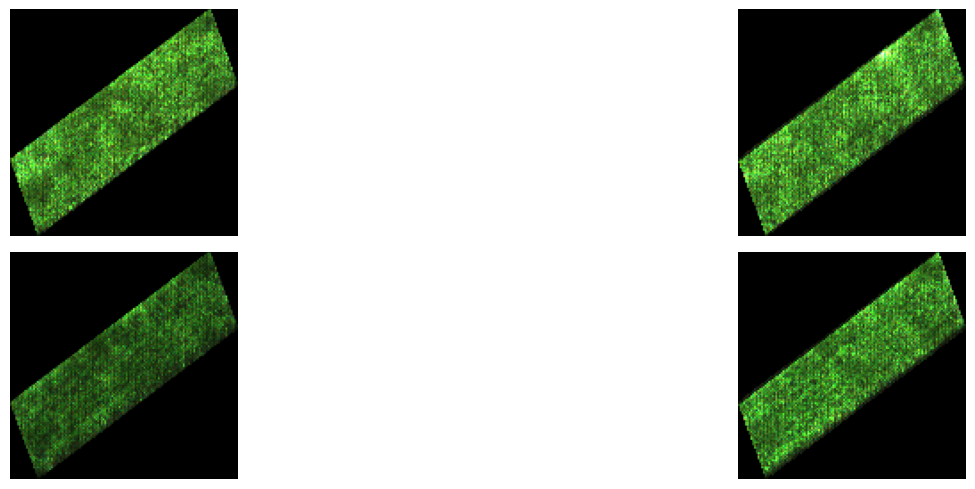

In [245]:
subplots = (2, 2)
plt.figure(figsize=(20,5))
synthetic_images_42, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1026-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_42_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1026-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
# Define an empty list to store the processed results
# Define an empty list to store the processed results
result_with_mask = []

# Calculate mask for black pixels in images

black_pixels_mask = create_non_black_mask(real_images_42[0]) == 0  # Assuming the first image is representative

# Modify images2 in the region where images has black pixels
for i, img in enumerate(synthetic_images_42_2):
    img[black_pixels_mask] = 0

# Process images using masks
result = [
    ((x * (y/2.3)) * 10) if x.all != 0 else x
    for x, y in zip(synthetic_images_42, synthetic_images_42_2)
]
samples_ppgan3_array_1005 = result
# Modify images2 in the region where images has black pixels
for i, img in enumerate(result):
    img[black_pixels_mask] = 0
    img[:, :, 2] = img[:, :, 2]/2.5
    img[:, :, 1] = img[:, :, 1]/1.7
    img[:, :, 0] = img[:, :, 0]/2

for i, image in enumerate(result[16:20]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        print(image.shape)
        plt.imshow(image[:, :, :])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper')

synthetic_bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'NIR']

# Calculate the mean spectral profiles for each data array
mean_real_images = np.mean(np.ma.masked_equal(real_images_42, 0), axis=(0, 1, 2))
mean_dcgan_0830 = np.mean(np.ma.masked_equal(samples_ppgan3_array_0830, 0), axis=(0, 1, 2))